In [1]:
import pandas as pd

# Read dataset
df = pd.read_excel(
    r"C:\& Satheesh\Customer-Churn-Risk-Model\data\Financial_Services_KPI_Dashboard_5000Rows.xlsx"
)

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Check data
df.head()

,customer_id,customer_name,product_type,fresco_segment,age_band,region,marketing_channel,campaign_date,days_to_maturity,account_value,...,online_login_days,complaints,email_open_rate,web_visits_30d,previous_campaign_response,conversion_flag,conversion_rate,campaign_cost,campaign_roi,estimated_revenue
0,100001,Nathan Gilbert DVM,CTF,Mature Wealth,60+,Glasgow,Email,2024-10-10,99,39771.22,...,125,2,77.91,12,Yes,1,9.34,452.44,1.41,2137.92
1,100002,Andrew Kelley,CTF,Mature Wealth,36-45,Manchester,SMS,2025-09-30,59,41230.72,...,157,2,50.13,15,No,0,15.31,223.29,1.18,2734.62
2,100003,Chelsea Lowery,ISA,Digital Achievers,60+,Liverpool,Branch,2023-10-05,151,51266.82,...,152,4,37.40,17,No,1,11.14,154.93,7.89,1359.88
3,100004,Christopher Barry,ISA,Mature Wealth,60+,Leeds,Digital Campaign,2024-05-03,27,73215.67,...,44,4,82.79,30,No,1,16.95,353.77,6.02,5770.11
4,100005,Tony Lopez MD,CTF,Mature Wealth,18-25,Liverpool,SMS,2025-05-13,199,55519.51,...,31,4,55.93,21,No,1,2.99,46.19,1.09,649.18


In [3]:
def calculate_churn_risk(row):

    score = 0

    # Failed DD
    if row["failed_dd"] == "Yes":
        score += 30

    # Complaints
    if row["complaints"] >= 3:
        score += 25
    elif row["complaints"] >= 1:
        score += 10

    # Online inactivity
    if row["online_login_days"] > 120:
        score += 25
    elif row["online_login_days"] > 60:
        score += 15

    # Low email engagement
    if row["email_open_rate"] < 20:
        score += 20

    # Low website engagement
    if row["web_visits_30d"] < 3:
        score += 15

    # No campaign response
    if row["previous_campaign_response"] == "No":
        score += 15

    # No active DD
    if row["active_dd"] == "No":
        score += 15

    return score

In [5]:
df["churn_risk_score"] = df.apply(calculate_churn_risk, axis=1)

df.head()

,customer_id,customer_name,product_type,fresco_segment,age_band,region,marketing_channel,campaign_date,days_to_maturity,account_value,...,complaints,email_open_rate,web_visits_30d,previous_campaign_response,conversion_flag,conversion_rate,campaign_cost,campaign_roi,estimated_revenue,churn_risk_score
0,100001,Nathan Gilbert DVM,CTF,Mature Wealth,60+,Glasgow,Email,2024-10-10,99,39771.22,...,2,77.91,12,Yes,1,9.34,452.44,1.41,2137.92,80
1,100002,Andrew Kelley,CTF,Mature Wealth,36-45,Manchester,SMS,2025-09-30,59,41230.72,...,2,50.13,15,No,0,15.31,223.29,1.18,2734.62,95
2,100003,Chelsea Lowery,ISA,Digital Achievers,60+,Liverpool,Branch,2023-10-05,151,51266.82,...,4,37.40,17,No,1,11.14,154.93,7.89,1359.88,110
3,100004,Christopher Barry,ISA,Mature Wealth,60+,Leeds,Digital Campaign,2024-05-03,27,73215.67,...,4,82.79,30,No,1,16.95,353.77,6.02,5770.11,40
4,100005,Tony Lopez MD,CTF,Mature Wealth,18-25,Liverpool,SMS,2025-05-13,199,55519.51,...,4,55.93,21,No,1,2.99,46.19,1.09,649.18,70


In [7]:
def churn_category(score):

    if score >= 80:
        return "High Risk"

    elif score >= 50:
        return "Medium Risk"

    else:
        return "Low Risk"


df["churn_risk_category"] = df["churn_risk_score"].apply(churn_category)

df.head()

,customer_id,customer_name,product_type,fresco_segment,age_band,region,marketing_channel,campaign_date,days_to_maturity,account_value,...,email_open_rate,web_visits_30d,previous_campaign_response,conversion_flag,conversion_rate,campaign_cost,campaign_roi,estimated_revenue,churn_risk_score,churn_risk_category
0,100001,Nathan Gilbert DVM,CTF,Mature Wealth,60+,Glasgow,Email,2024-10-10,99,39771.22,...,77.91,12,Yes,1,9.34,452.44,1.41,2137.92,80,High Risk
1,100002,Andrew Kelley,CTF,Mature Wealth,36-45,Manchester,SMS,2025-09-30,59,41230.72,...,50.13,15,No,0,15.31,223.29,1.18,2734.62,95,High Risk
2,100003,Chelsea Lowery,ISA,Digital Achievers,60+,Liverpool,Branch,2023-10-05,151,51266.82,...,37.40,17,No,1,11.14,154.93,7.89,1359.88,110,High Risk
3,100004,Christopher Barry,ISA,Mature Wealth,60+,Leeds,Digital Campaign,2024-05-03,27,73215.67,...,82.79,30,No,1,16.95,353.77,6.02,5770.11,40,Low Risk
4,100005,Tony Lopez MD,CTF,Mature Wealth,18-25,Liverpool,SMS,2025-05-13,199,55519.51,...,55.93,21,No,1,2.99,46.19,1.09,649.18,70,Medium Risk


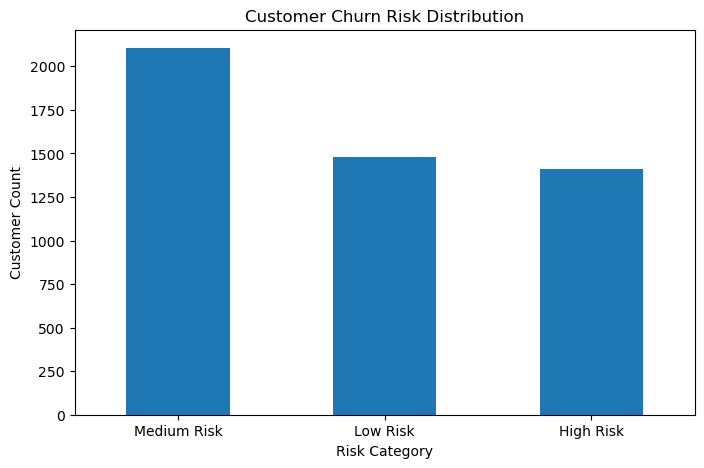

In [9]:
import matplotlib.pyplot as plt

df["churn_risk_category"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Customer Count")

plt.xticks(rotation=0)

plt.show()

In [11]:
output_path = r"C:\& Satheesh\Customer-Churn-Risk-Model\output\customer_churn_output.xlsx"

df.to_excel(output_path, index=False)

print("Churn model completed successfully.")

Churn model completed successfully.
